# Feature Similarity → Bottleneck Geometry

## Motivation

In real models, semantically similar features have **higher cosine similarity** in the residual stream, not just orthogonal or antipodal arrangements. Observations from the literature:

1. **Engels & Tegmark (2024)**: Days of the week are arranged in a circle in GPT-2's embedding space. Monday–Tuesday have higher cosine similarity than Monday–Wednesday. The geometry reflects semantic/temporal proximity.

2. **Feature splitting**: As SAE dictionary size increases, coarse features split into finer ones ("animal" → "dog"/"cat" → "golden retriever"/"poodle"). The split features remain nearby in representation space.

3. **Feature hierarchies**: Real features have nested structure. A "negative sentiment" feature and a "angry" feature share variance — their representations should be geometrically close.

The standard Toy Models setup assumes **independent features** with no correlation structure. This misses the core phenomenon: **the bottleneck geometry should reflect the similarity structure of the data**.

## Questions

1. If we give our autoencoder features with known correlation/similarity structure, does the learned bottleneck geometry reflect that structure?
2. Does this work differently for linear (l=1) vs nonlinear (l≥2) encoders?
3. When features have **cyclic** structure (like days of the week), does the bottleneck learn a circular arrangement?
4. When features have **hierarchical** structure, does the bottleneck learn nested clusters?
5. How does compression ratio interact with the fidelity of similarity preservation?

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from tqdm import tqdm
from core import (
    Autoencoder, device, generate_sparse_data,
    compute_feature_geometry, get_feature_importance
)

print(f"Device: {device}")

Device: cpu


## 1. Data generation: features with controlled similarity structure

We need to generate sparse data where the **co-occurrence** and **value correlation** between features follows a prescribed similarity matrix. Three structures:

- **Block-correlated**: Groups of features that tend to co-activate (e.g., topic clusters)
- **Cyclic**: Features arranged on a ring (e.g., days of the week, hue)
- **Hierarchical**: Nested groups (e.g., taxonomy)

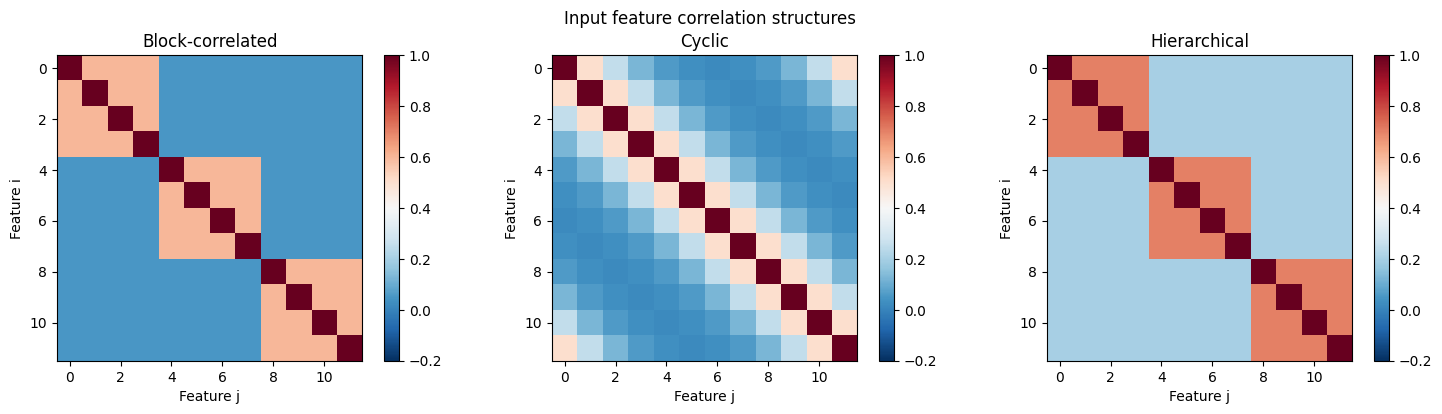

In [2]:
def generate_correlated_sparse_data(
    n_samples: int, n_features: int, correlation_matrix: torch.Tensor,
    S: float = 0.95, strength: float = 1.0
) -> torch.Tensor:
    """
    Generate sparse data where feature CO-ACTIVATION follows a correlation structure.
    
    Each feature is independently active with prob (1-S), but when a feature activates,
    correlated features have increased probability of also being active.
    
    Args:
        correlation_matrix: (n, n) matrix where entry (i,j) is the similarity between features i and j.
                           Diagonal should be 1. Off-diagonal in [0, 1].
        strength: how strongly correlations affect co-activation (0 = independent, 1 = full)
    """
    base_prob = 1 - S  # base activation probability
    
    # Step 1: Sample latent Gaussian with the prescribed correlation structure
    # Use Cholesky decomposition for correlated sampling
    C = correlation_matrix.cpu().numpy()
    # Ensure positive definite
    eigvals = np.linalg.eigvalsh(C)
    if eigvals.min() < 0:
        C += (abs(eigvals.min()) + 0.01) * np.eye(n_features)
    L = np.linalg.cholesky(C)
    
    # Sample correlated Gaussians
    z = np.random.randn(n_samples, n_features) @ L.T
    
    # Step 2: Threshold to get correlated sparsity pattern
    # Higher z → more likely to be active
    from scipy.stats import norm
    threshold = norm.ppf(S)  # threshold that gives sparsity S for standard normal
    
    # Blend between independent and correlated activation
    if strength < 1.0:
        z_independent = np.random.randn(n_samples, n_features)
        z = strength * z + (1 - strength) * z_independent
    
    mask = (z > threshold).astype(np.float32)
    
    # Step 3: Active features get random positive values
    values = np.random.rand(n_samples, n_features).astype(np.float32)
    data = torch.tensor(mask * values, device=device)
    
    return data


def make_block_correlation(n_features: int, n_blocks: int, within_corr: float = 0.6, between_corr: float = 0.0):
    """Block-diagonal correlation matrix: features in same block are correlated."""
    C = torch.eye(n_features) * (1 - between_corr) + between_corr
    block_size = n_features // n_blocks
    for b in range(n_blocks):
        start = b * block_size
        end = min(start + block_size, n_features)
        C[start:end, start:end] = within_corr
        for i in range(start, end):
            C[i, i] = 1.0
    return C


def make_cyclic_correlation(n_features: int, decay: float = 0.5):
    """
    Cyclic correlation: features on a ring, similarity decays with distance.
    Like days of the week: Monday-Tuesday are more similar than Monday-Thursday.
    
    Uses cosine kernel on circular distance.
    """
    C = torch.zeros(n_features, n_features)
    for i in range(n_features):
        for j in range(n_features):
            # Circular distance
            d = min(abs(i - j), n_features - abs(i - j))
            # Exponential decay with circular distance
            C[i, j] = decay ** d
    return C


def make_hierarchical_correlation(group_sizes: list, levels: list):
    """
    Hierarchical correlation: nested groups with decreasing similarity.
    
    Example: group_sizes=[3, 3, 3], levels=[0.8, 0.4, 0.0]
    → 3 groups of 3 features each
    → within-group similarity = 0.8
    → between-group similarity = 0.4  
    → baseline = 0.0
    """
    n = sum(group_sizes)
    C = torch.ones(n, n) * levels[-1]  # baseline
    
    # Within-group correlations
    offset = 0
    for g, size in enumerate(group_sizes):
        C[offset:offset+size, offset:offset+size] = levels[0]
        offset += size
    
    # Diagonal
    for i in range(n):
        C[i, i] = 1.0
    
    return C


# Visualize the three correlation structures
n = 12

C_block = make_block_correlation(n, n_blocks=3, within_corr=0.6, between_corr=0.05)
C_cyclic = make_cyclic_correlation(n, decay=0.5)
C_hier = make_hierarchical_correlation([4, 4, 4], levels=[0.7, 0.2])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, C, title in zip(axes, [C_block, C_cyclic, C_hier],
                         ['Block-correlated', 'Cyclic', 'Hierarchical']):
    im = ax.imshow(C.numpy(), cmap='RdBu_r', vmin=-0.2, vmax=1.0)
    ax.set_title(title)
    ax.set_xlabel('Feature j')
    ax.set_ylabel('Feature i')
    plt.colorbar(im, ax=ax)
plt.suptitle('Input feature correlation structures', fontsize=12)
plt.tight_layout()
plt.show()

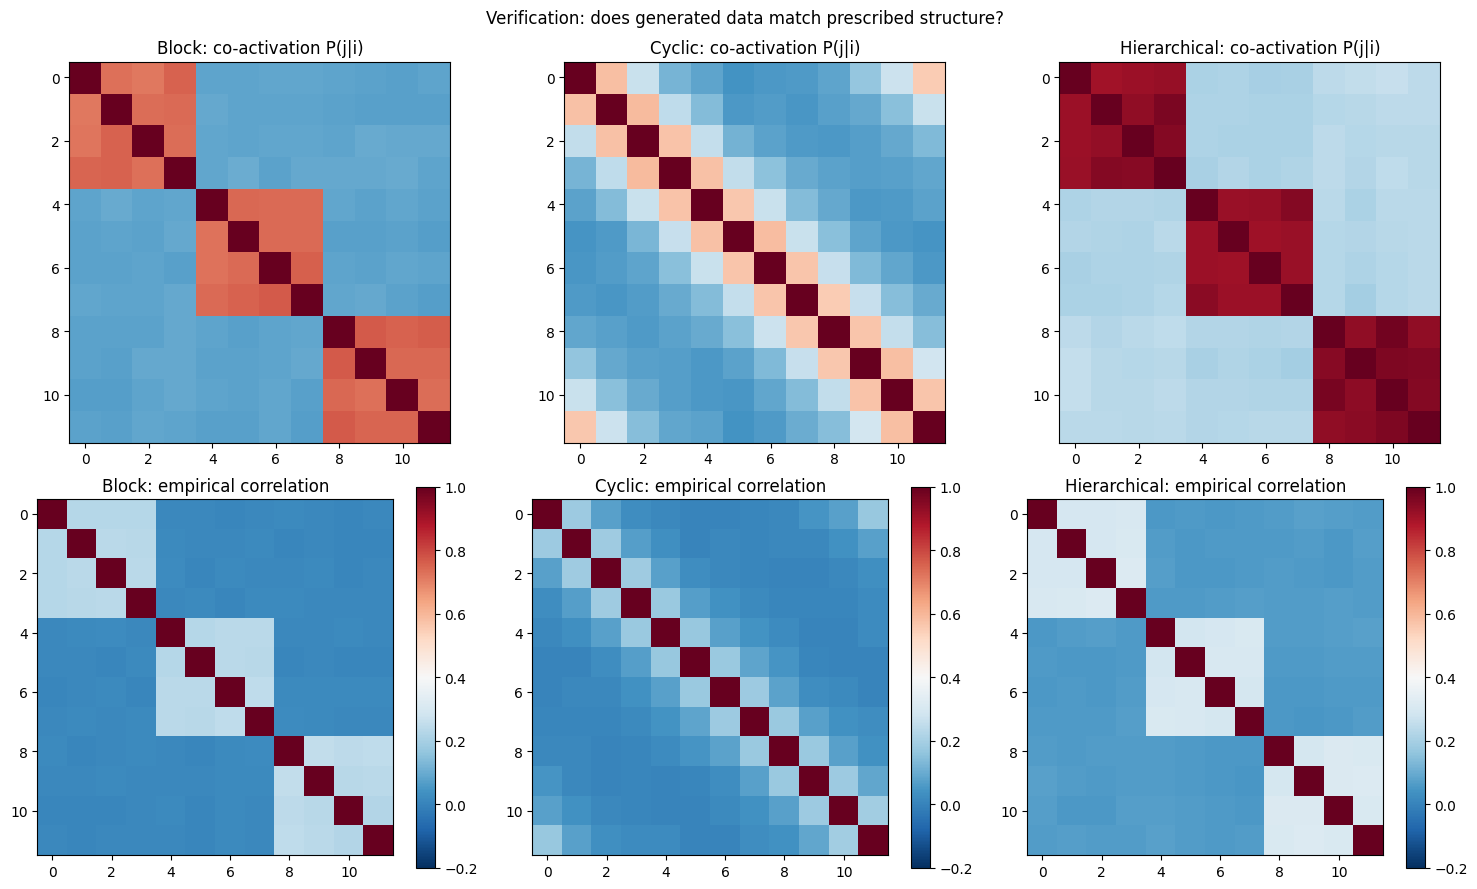

In [3]:
# Verify that generated data actually has the prescribed correlation structure
S = 0.90  # slightly less sparse so we have enough co-activations to measure
n_samples = 50000

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, (C_input, title) in enumerate([
    (C_block, 'Block'), (C_cyclic, 'Cyclic'), (C_hier, 'Hierarchical')
]):
    x = generate_correlated_sparse_data(n_samples, n, C_input, S=S, strength=1.0)
    
    # Empirical co-activation rate: P(j active | i active)
    active = (x > 0).float()
    co_act = (active.T @ active) / active.sum(dim=0, keepdim=True).T.clamp(min=1)
    
    # Empirical value correlation (among jointly-active samples)
    emp_corr = torch.corrcoef(x.T).cpu()
    
    axes[0, col].imshow(co_act.cpu().numpy(), cmap='RdBu_r', vmin=0, vmax=0.5)
    axes[0, col].set_title(f'{title}: co-activation P(j|i)')
    
    im = axes[1, col].imshow(emp_corr.numpy(), cmap='RdBu_r', vmin=-0.2, vmax=1.0)
    axes[1, col].set_title(f'{title}: empirical correlation')
    plt.colorbar(im, ax=axes[1, col])

plt.suptitle('Verification: does generated data match prescribed structure?', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Training with structured features

Train autoencoders on each correlation structure and examine the learned bottleneck geometry. The key prediction: **the cosine similarity between feature vectors in the bottleneck should reflect the input correlation structure**.

In [4]:
def train_with_correlation(
    model, C_input, n_steps=15000, batch_size=1024, S=0.95,
    lr=1e-3, weight_decay=1e-2, importance=None, verbose=True
):
    """Train autoencoder on data with prescribed correlation structure."""
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    losses = []
    
    iterator = tqdm(range(n_steps)) if verbose else range(n_steps)
    for step in iterator:
        x = generate_correlated_sparse_data(batch_size, model.n, C_input, S=S)
        optimizer.zero_grad()
        x_recon, z = model(x)
        
        if importance is not None:
            loss = (importance * (x - x_recon) ** 2).mean()
        else:
            loss = nn.functional.mse_loss(x_recon, x)
        
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
        if verbose and step % 2000 == 0:
            iterator.set_postfix({'loss': f'{loss.item():.6f}'})
    
    return losses


def get_bottleneck_cosine_similarity(model):
    """Get the cosine similarity matrix of feature vectors in the bottleneck.
    
    For l=1 tied weights, the feature vectors are the columns of W (encoder weight).
    Feature i is mapped to W[:, i] in the m-dimensional bottleneck.
    """
    W = None
    for name, param in model.encoder.named_parameters():
        if 'weight' in name:
            W = param.detach()
            break
    
    if W is None:
        return None
    
    # W is (m, n) — columns of W.T are the feature vectors in bottleneck space
    # Actually: encoder is Linear(n, m), so W is (m, n)
    # Feature i maps to W[:, i] (the i-th column)
    features = W.T  # (n, m) — each row is a feature's bottleneck vector
    
    # Normalize
    norms = features.norm(dim=1, keepdim=True).clamp(min=1e-8)
    features_normed = features / norms
    
    # Cosine similarity matrix
    cos_sim = features_normed @ features_normed.T
    return cos_sim.cpu()

In [5]:
# Experiment: train on each structure, compare input correlation → bottleneck similarity
n = 12
m = 5  # compression ratio 12/5 = 2.4x — forces superposition
S = 0.95
n_steps = 20000
n_seeds = 20

structures = {
    'Independent': torch.eye(n),
    'Block (3 groups)': make_block_correlation(n, n_blocks=3, within_corr=0.6, between_corr=0.05),
    'Cyclic': make_cyclic_correlation(n, decay=0.5),
    'Hierarchical': make_hierarchical_correlation([4, 4, 4], levels=[0.7, 0.2]),
}

results = {}

for struct_name, C_input in structures.items():
    print(f"\n{'='*50}")
    print(f"Structure: {struct_name}")
    print(f"{'='*50}")
    
    best_loss = float('inf')
    best_model = None
    
    for seed in tqdm(range(n_seeds), desc='Seeds'):
        torch.manual_seed(seed)
        np.random.seed(seed)
        model = Autoencoder(n, m, l=1, tied_weights=True).to(device)
        
        if struct_name == 'Independent':
            from core import train_autoencoder
            losses = train_autoencoder(model, n_steps=n_steps, S=S, verbose=False)
        else:
            losses = train_with_correlation(model, C_input, n_steps=n_steps, S=S, verbose=False)
        
        final_loss = np.mean(losses[-200:])
        if final_loss < best_loss:
            best_loss = final_loss
            best_model = model
            best_losses = losses
    
    cos_sim = get_bottleneck_cosine_similarity(best_model)
    geom = compute_feature_geometry(best_model)
    
    results[struct_name] = {
        'model': best_model,
        'losses': best_losses,
        'final_loss': best_loss,
        'C_input': C_input,
        'cos_sim_bottleneck': cos_sim,
        **geom,
    }
    
    print(f"Best loss: {best_loss:.6f}")


Structure: Independent


Seeds:   0%|          | 0/20 [00:00<?, ?it/s]

Seeds:   5%|▌         | 1/20 [00:03<01:11,  3.76s/it]

Seeds:  10%|█         | 2/20 [00:06<01:00,  3.36s/it]

Seeds:  15%|█▌        | 3/20 [00:09<00:55,  3.27s/it]

...

Seeds:  90%|█████████ | 18/20 [02:10<00:14,  7.23s/it]

Seeds:  95%|█████████▌| 19/20 [02:17<00:07,  7.22s/it]

Seeds: 100%|██████████| 20/20 [02:24<00:00,  7.23s/it]

Seeds: 100%|██████████| 20/20 [02:24<00:00,  7.24s/it]

Best loss: 0.001841


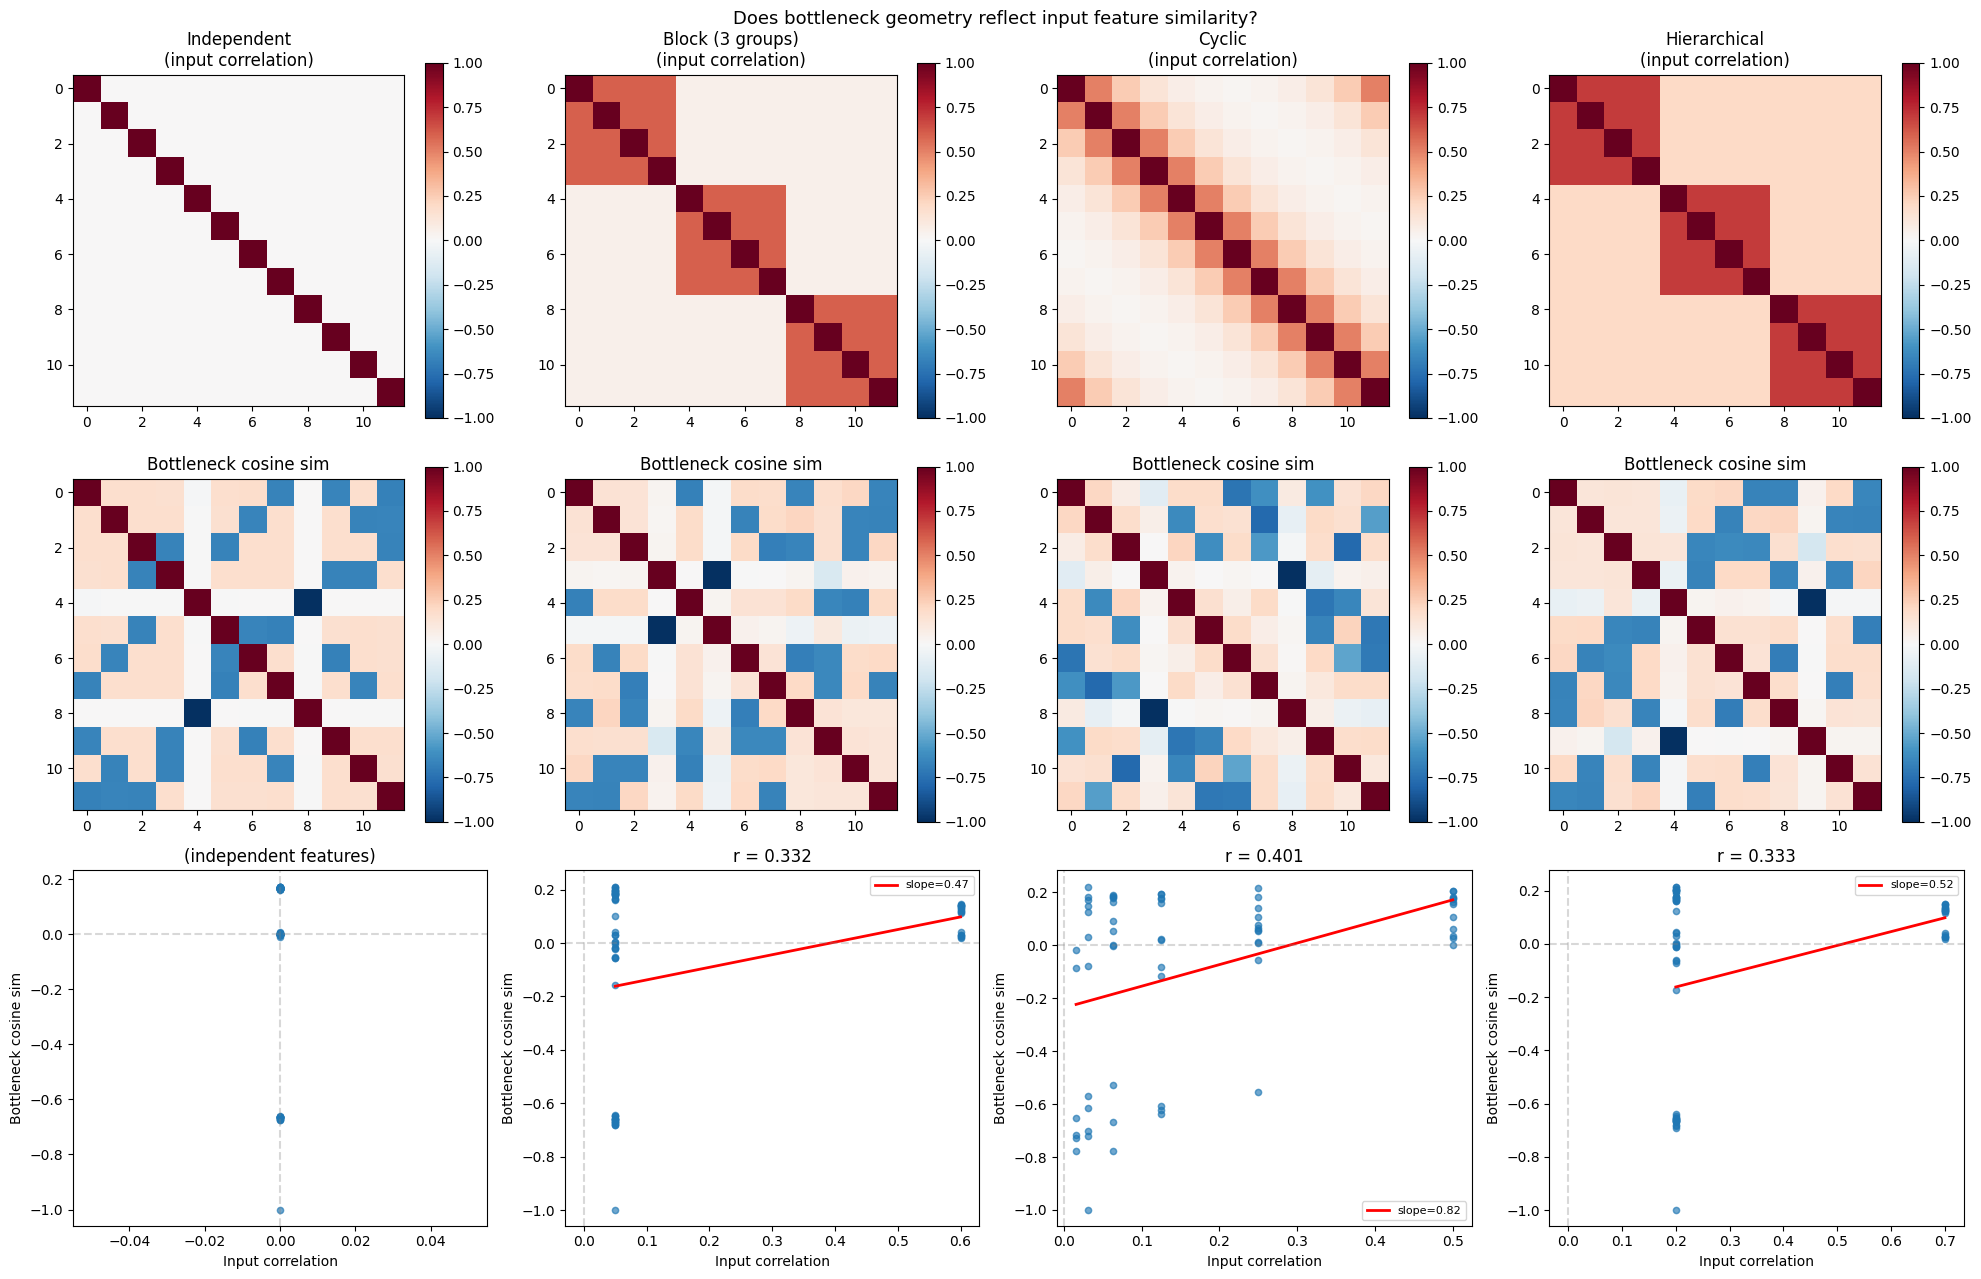

In [6]:
# The key plot: input correlation vs bottleneck cosine similarity
fig, axes = plt.subplots(3, len(structures), figsize=(5*len(structures), 13))

for col, (struct_name, res) in enumerate(results.items()):
    C_in = res['C_input'].numpy()
    C_bot = res['cos_sim_bottleneck'].numpy()
    
    # Row 1: Input correlation
    im = axes[0, col].imshow(C_in, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[0, col].set_title(f'{struct_name}\n(input correlation)')
    plt.colorbar(im, ax=axes[0, col])
    
    # Row 2: Bottleneck cosine similarity
    im = axes[1, col].imshow(C_bot, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[1, col].set_title('Bottleneck cosine sim')
    plt.colorbar(im, ax=axes[1, col])
    
    # Row 3: Scatter of input corr vs bottleneck sim (off-diagonal elements)
    ax = axes[2, col]
    mask = ~np.eye(n, dtype=bool)
    x_vals = C_in[mask]
    y_vals = C_bot[mask]
    ax.scatter(x_vals, y_vals, alpha=0.4, s=20)
    
    # Fit line
    if np.std(x_vals) > 1e-6:
        coeffs = np.polyfit(x_vals, y_vals, 1)
        x_fit = np.linspace(x_vals.min(), x_vals.max(), 100)
        ax.plot(x_fit, np.polyval(coeffs, x_fit), 'r-', linewidth=2,
                label=f'slope={coeffs[0]:.2f}')
        corr = np.corrcoef(x_vals, y_vals)[0, 1]
        ax.set_title(f'r = {corr:.3f}')
        ax.legend(fontsize=8)
    else:
        ax.set_title('(independent features)')
    
    ax.set_xlabel('Input correlation')
    ax.set_ylabel('Bottleneck cosine sim')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.3)

plt.suptitle('Does bottleneck geometry reflect input feature similarity?', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Cyclic features: does the bottleneck learn a circle?

The Engels/Tegmark result: days of the week form a circle in embedding space. If we give our autoencoder features with cyclic correlation structure, does the bottleneck arrange them in a circle?

For n features on a ring compressed into m=2 bottleneck dimensions, the optimal arrangement is an n-gon.

In [7]:
# Train specifically with cyclic features and m=2 so we can visualize directly
n_cyclic = 7  # days of the week!
m_cyclic = 2  # 2D bottleneck for visualization
S = 0.90  # lower sparsity so correlation structure is learnable
n_steps = 25000
n_seeds = 30

C_cyclic_7 = make_cyclic_correlation(n_cyclic, decay=0.5)

# Also train with independent features as control
cyclic_results = {}

for struct_name, C_input, use_corr in [
    ('Independent', torch.eye(n_cyclic), False),
    ('Cyclic (decay=0.5)', C_cyclic_7, True),
    ('Cyclic (decay=0.7)', make_cyclic_correlation(n_cyclic, decay=0.7), True),
    ('Cyclic (decay=0.3)', make_cyclic_correlation(n_cyclic, decay=0.3), True),
]:
    print(f"Training: {struct_name}")
    best_loss = float('inf')
    best_model = None
    
    for seed in tqdm(range(n_seeds), desc='Seeds', leave=False):
        torch.manual_seed(seed)
        np.random.seed(seed)
        model = Autoencoder(n_cyclic, m_cyclic, l=1, tied_weights=True).to(device)
        
        if use_corr:
            losses = train_with_correlation(model, C_input, n_steps=n_steps, S=S, verbose=False)
        else:
            from core import train_autoencoder
            losses = train_autoencoder(model, n_steps=n_steps, S=S, verbose=False)
        
        final_loss = np.mean(losses[-200:])
        if final_loss < best_loss:
            best_loss = final_loss
            best_model = model
    
    cyclic_results[struct_name] = {
        'model': best_model,
        'final_loss': best_loss,
        'C_input': C_input,
    }
    print(f"  loss={best_loss:.6f}")

Training: Independent


Seeds:   0%|          | 0/30 [00:00<?, ?it/s]

Seeds:   3%|▎         | 1/30 [00:04<01:58,  4.07s/it]

Seeds:   7%|▋         | 2/30 [00:08<01:56,  4.17s/it]

Seeds:  10%|█         | 3/30 [00:12<01:50,  4.11s/it]

...

Seeds:  90%|█████████ | 27/30 [03:11<00:21,  7.14s/it]

Seeds:  93%|█████████▎| 28/30 [03:19<00:14,  7.12s/it]

Seeds:  97%|█████████▋| 29/30 [03:26<00:07,  7.13s/it]

Seeds: 100%|██████████| 30/30 [03:33<00:00,  7.14s/it]

  loss=0.011937


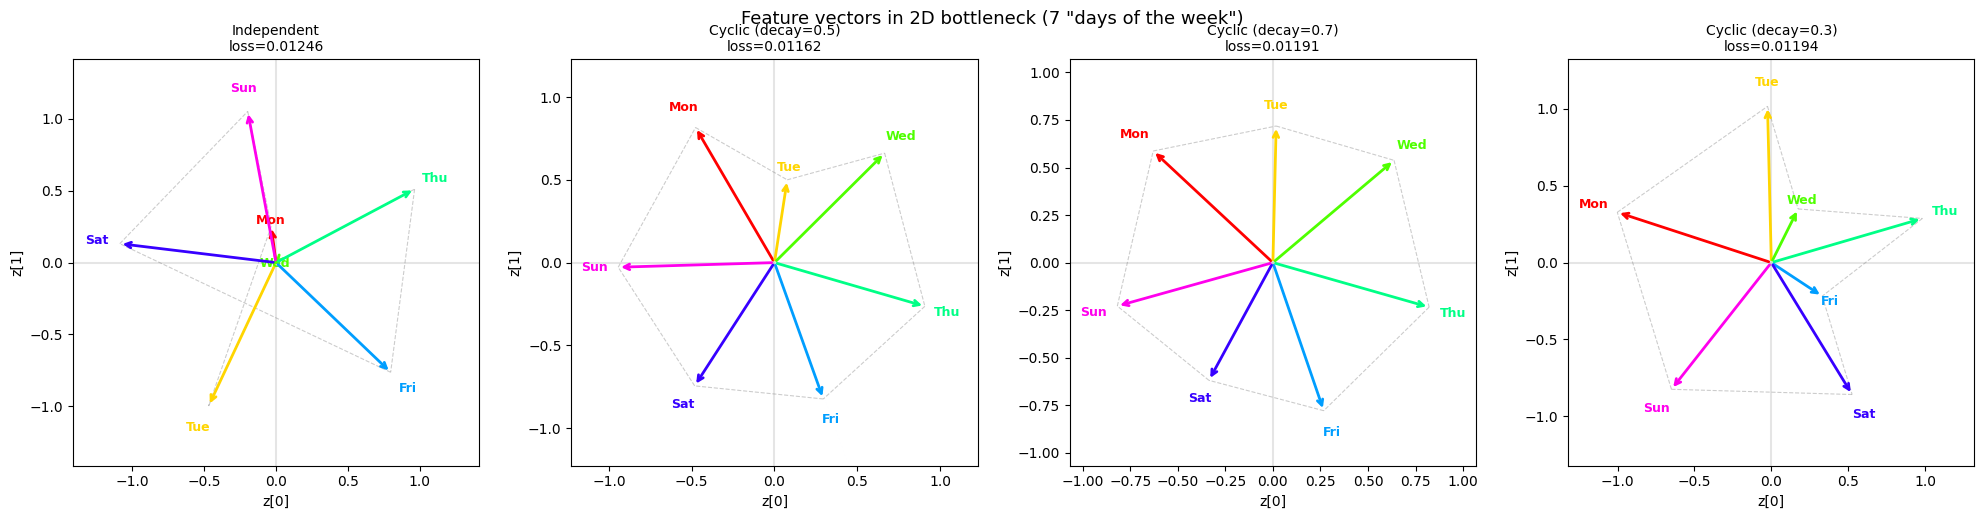

In [8]:
# Visualize: feature vectors in 2D bottleneck space
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, len(cyclic_results), figsize=(5*len(cyclic_results), 5))

for col, (struct_name, res) in enumerate(cyclic_results.items()):
    ax = axes[col]
    model = res['model']
    
    # Get feature vectors (columns of W)
    W = None
    for name, param in model.encoder.named_parameters():
        if 'weight' in name:
            W = param.detach().cpu().numpy()
            break
    
    if W is not None:
        # W is (m=2, n=7), feature i is W[:, i]
        for i in range(n_cyclic):
            ax.annotate('', xy=(W[0, i], W[1, i]), xytext=(0, 0),
                       arrowprops=dict(arrowstyle='->', color=plt.cm.hsv(i/n_cyclic), lw=2))
            ax.text(W[0, i]*1.15, W[1, i]*1.15, day_labels[i],
                   ha='center', va='center', fontsize=9, fontweight='bold',
                   color=plt.cm.hsv(i/n_cyclic))
        
        # Draw connecting lines in order (Mon→Tue→...→Sun→Mon)
        for i in range(n_cyclic):
            j = (i + 1) % n_cyclic
            ax.plot([W[0, i], W[0, j]], [W[1, i], W[1, j]],
                   'k--', alpha=0.2, linewidth=0.8)
    
    max_r = np.max(np.abs(W)) * 1.3 if W is not None else 1
    ax.set_xlim(-max_r, max_r)
    ax.set_ylim(-max_r, max_r)
    ax.set_aspect('equal')
    ax.set_title(f'{struct_name}\nloss={res["final_loss"]:.5f}', fontsize=10)
    ax.axhline(0, color='gray', alpha=0.2)
    ax.axvline(0, color='gray', alpha=0.2)
    ax.set_xlabel('z[0]')
    ax.set_ylabel('z[1]')

plt.suptitle('Feature vectors in 2D bottleneck (7 "days of the week")', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# Quantify circularity: for the cyclic case, compute the angular ordering
# If features are in a circle, consecutive features should have consecutive angles

print("Angular ordering analysis:")
print("If features form a circle, sequential features should have sequential angles.\n")

for struct_name, res in cyclic_results.items():
    model = res['model']
    W = None
    for name, param in model.encoder.named_parameters():
        if 'weight' in name:
            W = param.detach().cpu().numpy()
            break
    
    if W is None:
        continue
    
    # Compute angle of each feature vector
    angles = np.arctan2(W[1, :], W[0, :]) * 180 / np.pi
    
    # Sort features by angle
    order = np.argsort(angles)
    
    # Check if angular order matches sequential order (or its reverse)
    # Compute circular correlation between angular order and feature index
    sequential_order = list(range(n_cyclic))
    
    # Find best circular alignment
    best_match = 0
    for shift in range(n_cyclic):
        shifted = [(o + shift) % n_cyclic for o in order]
        # Count adjacencies preserved
        adjacencies = sum(1 for k in range(n_cyclic)
                         if abs(shifted[k] - shifted[(k+1) % n_cyclic]) <= 1
                         or abs(shifted[k] - shifted[(k+1) % n_cyclic]) == n_cyclic - 1)
        best_match = max(best_match, adjacencies)
    
    print(f"{struct_name}:")
    print(f"  Angular order: {[day_labels[i] for i in order]}")
    print(f"  Angles: {[f'{a:.0f}°' for a in angles[order]]}")
    print(f"  Adjacent pairs preserved: {best_match}/{n_cyclic} (7/7 = perfect circle)")
    
    # Cosine similarity between adjacent vs non-adjacent
    cos_sim = get_bottleneck_cosine_similarity(model).numpy()
    adj_sims = [cos_sim[i, (i+1) % n_cyclic] for i in range(n_cyclic)]
    non_adj_sims = [cos_sim[i, (i+2) % n_cyclic] for i in range(n_cyclic)]
    far_sims = [cos_sim[i, (i + n_cyclic//2) % n_cyclic] for i in range(n_cyclic)]
    print(f"  Mean cos_sim: adjacent={np.mean(adj_sims):.3f}, "
          f"skip-1={np.mean(non_adj_sims):.3f}, opposite={np.mean(far_sims):.3f}")
    print()

Angular ordering analysis:
If features form a circle, sequential features should have sequential angles.

Independent:
  Angular order: ['Wed', 'Tue', 'Fri', 'Thu', 'Mon', 'Sun', 'Sat']
  Angles: ['-132°', '-115°', '-44°', '28°', '97°', '101°', '173°']
  Adjacent pairs preserved: 4/7 (7/7 = perfect circle)
  Mean cos_sim: adjacent=-0.002, skip-1=-0.516, opposite=0.067

Cyclic (decay=0.5):
  Angular order: ['Sun', 'Sat', 'Fri', 'Thu', 'Wed', 'Tue', 'Mon']
  Angles: ['-178°', '-123°', '-70°', '-16°', '45°', '81°', '120°']
  Adjacent pairs preserved: 7/7 (7/7 = perfect circle)
  Mean cos_sim: adjacent=0.615, skip-1=-0.219, opposite=-0.880

Cyclic (decay=0.7):
  Angular order: ['Sun', 'Sat', 'Fri', 'Thu', 'Wed', 'Tue', 'Mon']
  Angles: ['-164°', '-119°', '-71°', '-16°', '40°', '89°', '137°']
  Adjacent pairs preserved: 7/7 (7/7 = perfect circle)
  Mean cos_sim: adjacent=0.621, skip-1=-0.222, opposite=-0.899

Cyclic (decay=0.3):
  Angular order: ['Sun', 'Sat', 'Fri', 'Thu', 'Wed', 'Tue', 'M

## 4. Does compression ratio affect similarity preservation?

At low compression (m ≈ n), features can be orthogonal and similarity doesn't need to be preserved geometrically. At high compression (m << n), superposition forces features to share dimensions — and correlated features should share *more*.

Prediction: similarity preservation should increase with compression.

In [10]:
n = 12
m_values = [2, 3, 4, 6, 8, 10, 12]
S = 0.95
n_steps = 20000
n_seeds = 20

C_block = make_block_correlation(n, n_blocks=3, within_corr=0.6, between_corr=0.05)

compression_results = {}

for m in m_values:
    print(f"m={m} (compression {n/m:.1f}x)")
    best_loss = float('inf')
    best_model = None
    
    for seed in range(n_seeds):
        torch.manual_seed(seed)
        np.random.seed(seed)
        model = Autoencoder(n, m, l=1, tied_weights=True).to(device)
        losses = train_with_correlation(model, C_block, n_steps=n_steps, S=S, verbose=False)
        final_loss = np.mean(losses[-200:])
        if final_loss < best_loss:
            best_loss = final_loss
            best_model = model
    
    cos_sim = get_bottleneck_cosine_similarity(best_model)
    compression_results[m] = {
        'model': best_model,
        'final_loss': best_loss,
        'cos_sim_bottleneck': cos_sim,
    }

m=2 (compression 6.0x)


m=3 (compression 4.0x)


m=4 (compression 3.0x)


m=6 (compression 2.0x)


m=8 (compression 1.5x)


m=10 (compression 1.2x)


m=12 (compression 1.0x)


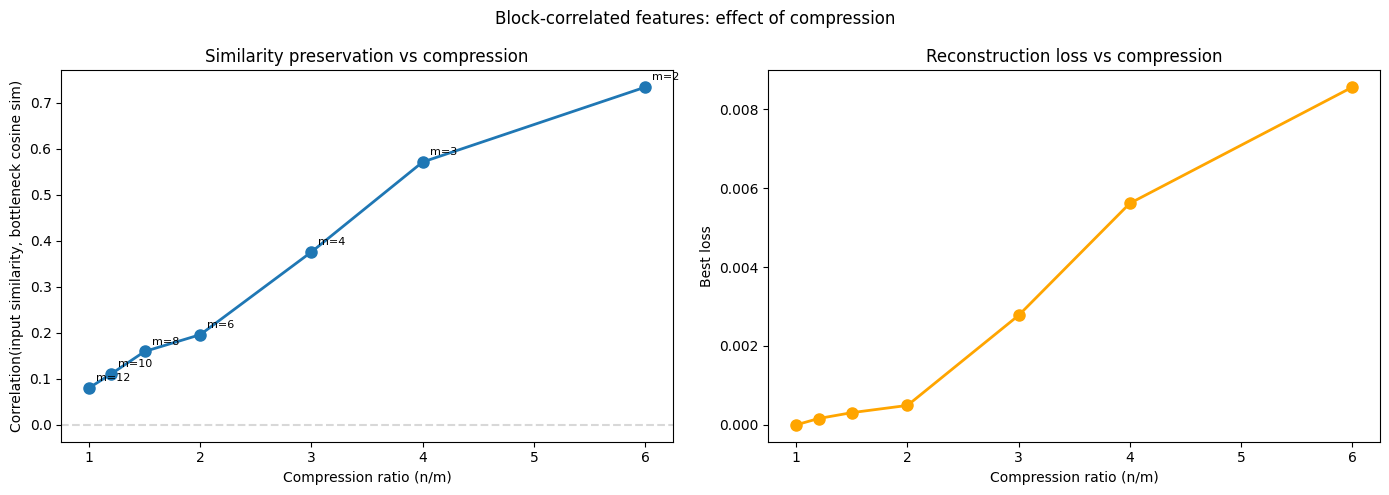

In [11]:
# Correlation between input structure and bottleneck geometry vs compression
C_in = C_block.numpy()
mask = ~np.eye(n, dtype=bool)
x_vals = C_in[mask]

correlations = []
ratios = []

for m, res in compression_results.items():
    C_bot = res['cos_sim_bottleneck'].numpy()
    y_vals = C_bot[mask]
    r = np.corrcoef(x_vals, y_vals)[0, 1]
    correlations.append(r)
    ratios.append(n / m)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ratios, correlations, 'o-', markersize=8, linewidth=2)
ax.set_xlabel('Compression ratio (n/m)')
ax.set_ylabel('Correlation(input similarity, bottleneck cosine sim)')
ax.set_title('Similarity preservation vs compression')
ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
for i, m in enumerate(m_values):
    ax.annotate(f'm={m}', (ratios[i], correlations[i]), textcoords='offset points',
               xytext=(5, 5), fontsize=8)

# Also show loss vs compression
ax = axes[1]
losses_list = [compression_results[m]['final_loss'] for m in m_values]
ax.plot(ratios, losses_list, 'o-', markersize=8, linewidth=2, color='orange')
ax.set_xlabel('Compression ratio (n/m)')
ax.set_ylabel('Best loss')
ax.set_title('Reconstruction loss vs compression')

plt.suptitle('Block-correlated features: effect of compression', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Feature splitting simulation

Simulate feature splitting: start with coarse features (few groups, high within-group correlation), then "split" into finer features (more groups, lower correlation). As the feature space becomes more granular, how does the bottleneck geometry adapt?

This mimics what happens when you increase SAE dictionary size: coarse features split into fine-grained ones that remain geometrically nearby.

In [12]:
n = 12
m = 4
S = 0.95
n_steps = 20000
n_seeds = 20

# "Splitting" progression: from coarse to fine features
splitting_configs = [
    ('2 coarse groups', make_block_correlation(n, 2, within_corr=0.8, between_corr=0.0)),
    ('3 groups', make_block_correlation(n, 3, within_corr=0.6, between_corr=0.1)),
    ('4 groups', make_block_correlation(n, 4, within_corr=0.5, between_corr=0.1)),
    ('6 fine groups', make_block_correlation(n, 6, within_corr=0.4, between_corr=0.1)),
    ('12 independent', torch.eye(n)),
]

split_results = {}

for name, C_input in splitting_configs:
    print(f"Training: {name}")
    best_loss = float('inf')
    best_model = None
    
    for seed in range(n_seeds):
        torch.manual_seed(seed)
        np.random.seed(seed)
        model = Autoencoder(n, m, l=1, tied_weights=True).to(device)
        
        if name == '12 independent':
            from core import train_autoencoder
            losses = train_autoencoder(model, n_steps=n_steps, S=S, verbose=False)
        else:
            losses = train_with_correlation(model, C_input, n_steps=n_steps, S=S, verbose=False)
        
        final_loss = np.mean(losses[-200:])
        if final_loss < best_loss:
            best_loss = final_loss
            best_model = model
    
    split_results[name] = {
        'model': best_model,
        'final_loss': best_loss,
        'C_input': C_input,
        'cos_sim_bottleneck': get_bottleneck_cosine_similarity(best_model),
    }
    print(f"  loss={best_loss:.6f}")

Training: 2 coarse groups


  loss=0.003057
Training: 3 groups


  loss=0.003008
Training: 4 groups


  loss=0.002913
Training: 6 fine groups


  loss=0.003055
Training: 12 independent


  loss=0.002462


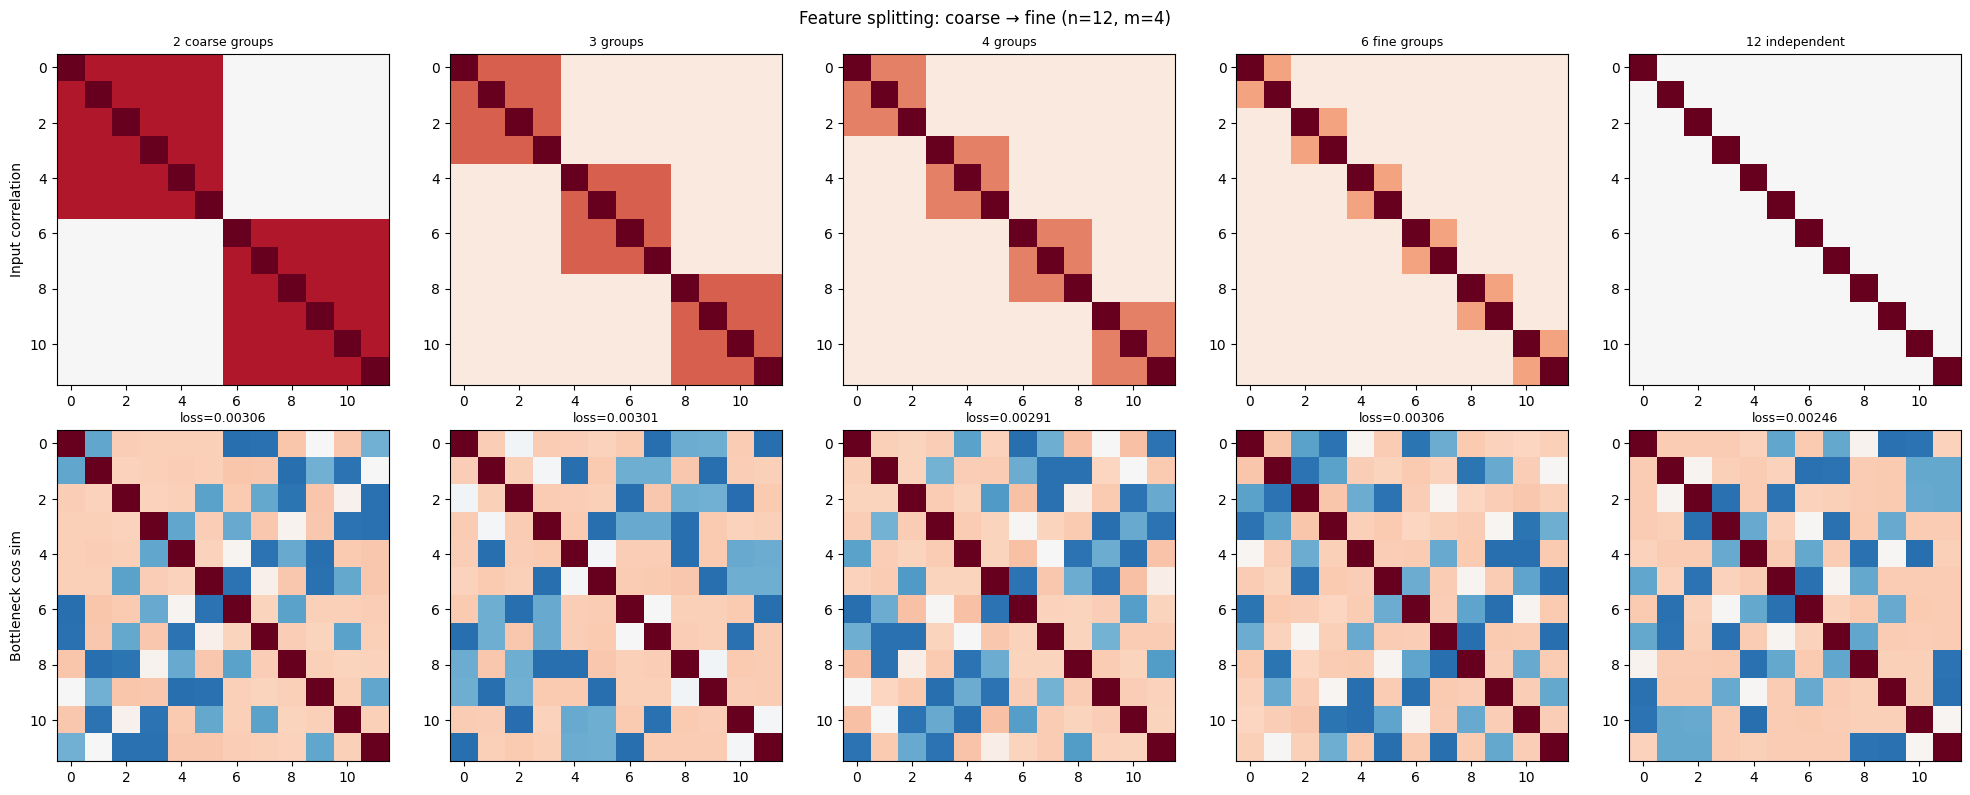

In [13]:
fig, axes = plt.subplots(2, len(split_results), figsize=(4*len(split_results), 8))

for col, (name, res) in enumerate(split_results.items()):
    # Row 1: input correlation
    im = axes[0, col].imshow(res['C_input'].numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
    axes[0, col].set_title(f'{name}', fontsize=9)
    if col == 0:
        axes[0, col].set_ylabel('Input correlation')
    
    # Row 2: bottleneck cosine similarity
    im = axes[1, col].imshow(res['cos_sim_bottleneck'].numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
    axes[1, col].set_title(f'loss={res["final_loss"]:.5f}', fontsize=9)
    if col == 0:
        axes[1, col].set_ylabel('Bottleneck cos sim')

plt.suptitle(f'Feature splitting: coarse → fine (n={n}, m={m})', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Does nonlinear encoding help preserve similarity structure?

Core question from the project: does encoder depth (l≥2) provide better similarity preservation than l=1? The linear encoder is constrained to a linear projection — a nonlinear encoder could potentially learn a mapping that better preserves the similarity structure of the input.

In [14]:
n = 12
m = 4
S = 0.95
n_steps = 20000
n_seeds = 20

C_block = make_block_correlation(n, n_blocks=3, within_corr=0.6, between_corr=0.05)
C_cyclic = make_cyclic_correlation(n, decay=0.5)

depth_results = {}

for struct_name, C_input in [('Block', C_block), ('Cyclic', C_cyclic)]:
    for l in [1, 2, 3]:
        key = f'{struct_name} l={l}'
        print(f"Training: {key}")
        
        best_loss = float('inf')
        best_model = None
        tw = (l == 1)
        
        for seed in range(n_seeds):
            torch.manual_seed(seed)
            np.random.seed(seed)
            model = Autoencoder(n, m, l=l, tied_weights=tw).to(device)
            losses = train_with_correlation(model, C_input, n_steps=n_steps, S=S, verbose=False)
            final_loss = np.mean(losses[-200:])
            if final_loss < best_loss:
                best_loss = final_loss
                best_model = model
        
        # For deep models, compute bottleneck similarity empirically
        # (can't just look at W columns because encoder is nonlinear)
        model.eval()
        with torch.no_grad():
            # Encode unit vectors to get feature representations
            eye = torch.eye(n, device=device)
            z_features = model.encode(eye)  # (n, m) — each row is feature i's bottleneck repr
            norms = z_features.norm(dim=1, keepdim=True).clamp(min=1e-8)
            z_normed = z_features / norms
            cos_sim = (z_normed @ z_normed.T).cpu()
        
        depth_results[key] = {
            'model': best_model,
            'final_loss': best_loss,
            'cos_sim_bottleneck': cos_sim,
            'C_input': C_input,
            'l': l,
            'struct': struct_name,
        }
        
        # Compute correlation
        mask_off = ~np.eye(n, dtype=bool)
        r = np.corrcoef(C_input.numpy()[mask_off], cos_sim.numpy()[mask_off])[0, 1]
        print(f"  loss={best_loss:.6f}, similarity_correlation={r:.3f}")

Training: Block l=1


  loss=0.002776, similarity_correlation=0.352
Training: Block l=2


  loss=0.001226, similarity_correlation=0.302
Training: Block l=3


  loss=0.001147, similarity_correlation=0.094
Training: Cyclic l=1


  loss=0.002797, similarity_correlation=0.363
Training: Cyclic l=2


  loss=0.001296, similarity_correlation=0.421
Training: Cyclic l=3


  loss=0.001274, similarity_correlation=0.071


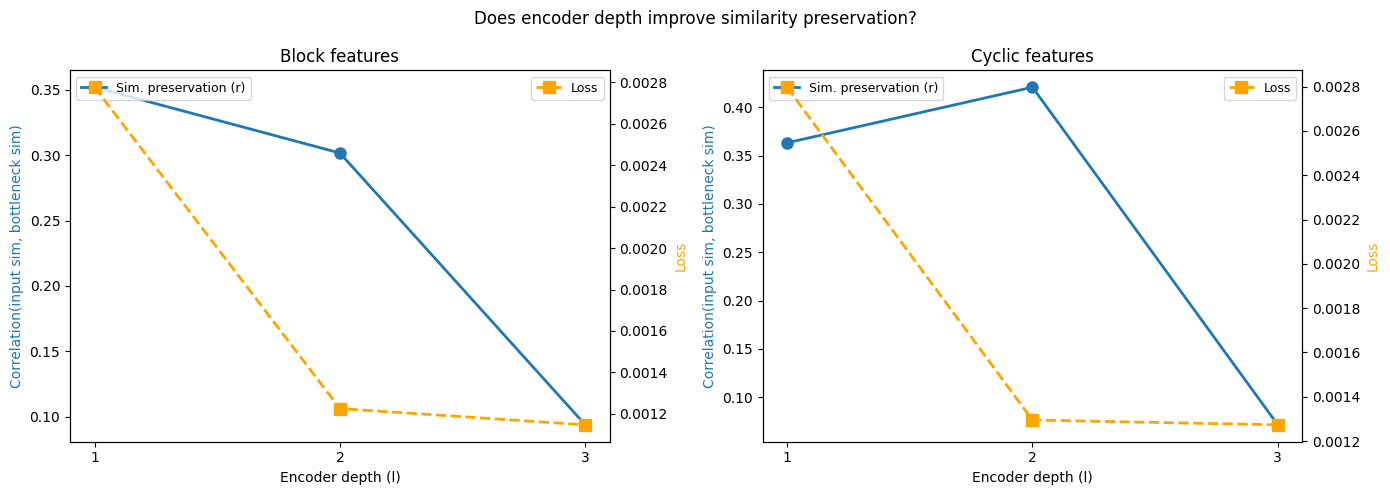

In [15]:
# Plot: similarity preservation correlation vs depth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mask_off = ~np.eye(n, dtype=bool)

for col, struct_name in enumerate(['Block', 'Cyclic']):
    ax = axes[col]
    ls = [1, 2, 3]
    
    C_in = depth_results[f'{struct_name} l=1']['C_input'].numpy()
    
    corrs = []
    losses_list = []
    for l in ls:
        key = f'{struct_name} l={l}'
        C_bot = depth_results[key]['cos_sim_bottleneck'].numpy()
        r = np.corrcoef(C_in[mask_off], C_bot[mask_off])[0, 1]
        corrs.append(r)
        losses_list.append(depth_results[key]['final_loss'])
    
    ax.plot(ls, corrs, 'o-', markersize=8, linewidth=2, label='Sim. preservation (r)')
    ax.set_xlabel('Encoder depth (l)')
    ax.set_ylabel('Correlation(input sim, bottleneck sim)', color='C0')
    ax.set_title(f'{struct_name} features')
    ax.set_xticks(ls)
    
    ax2 = ax.twinx()
    ax2.plot(ls, losses_list, 's--', markersize=8, linewidth=2, color='orange', label='Loss')
    ax2.set_ylabel('Loss', color='orange')
    
    ax.legend(loc='upper left', fontsize=9)
    ax2.legend(loc='upper right', fontsize=9)

plt.suptitle('Does encoder depth improve similarity preservation?', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Connection to Engels/Tegmark: recovering circular structure

In their work, the circular structure of days/months emerges in LLM embeddings. Let's test the converse: if we train on data with circular statistics, the autoencoder should learn circular geometry — and we can measure how well.

We can also test: does the **radius** of each feature on the circle relate to its importance/frequency?

In [16]:
# Train with cyclic features + importance weighting
# Prediction: more important features should have larger norms (further from origin)
# just like in the Toy Models paper

n_cyclic = 7
m_cyclic = 2
S = 0.90
n_steps = 25000
n_seeds = 30

C_cyclic_7 = make_cyclic_correlation(n_cyclic, decay=0.5)
importance = get_feature_importance(n_cyclic, decay=0.7, device=device)

# With and without importance weighting
imp_results = {}

for name, imp in [('Uniform importance', None), ('Decaying importance (0.7^i)', importance)]:
    print(f"Training: {name}")
    best_loss = float('inf')
    best_model = None
    
    for seed in tqdm(range(n_seeds), desc='Seeds', leave=False):
        torch.manual_seed(seed)
        np.random.seed(seed)
        model = Autoencoder(n_cyclic, m_cyclic, l=1, tied_weights=True).to(device)
        losses = train_with_correlation(
            model, C_cyclic_7, n_steps=n_steps, S=S,
            importance=imp, verbose=False
        )
        final_loss = np.mean(losses[-200:])
        if final_loss < best_loss:
            best_loss = final_loss
            best_model = model
    
    imp_results[name] = {'model': best_model, 'final_loss': best_loss}
    print(f"  loss={best_loss:.6f}")

Training: Uniform importance


Seeds:   0%|          | 0/30 [00:00<?, ?it/s]

Seeds:   3%|▎         | 1/30 [00:07<03:33,  7.35s/it]

Seeds:   7%|▋         | 2/30 [00:14<03:24,  7.32s/it]

Seeds:  10%|█         | 3/30 [00:21<03:17,  7.31s/it]

...

Seeds:  90%|█████████ | 27/30 [03:26<00:23,  7.93s/it]

Seeds:  93%|█████████▎| 28/30 [03:34<00:15,  7.89s/it]

Seeds:  97%|█████████▋| 29/30 [03:41<00:07,  7.79s/it]

Seeds: 100%|██████████| 30/30 [03:49<00:00,  7.76s/it]

  loss=0.003371


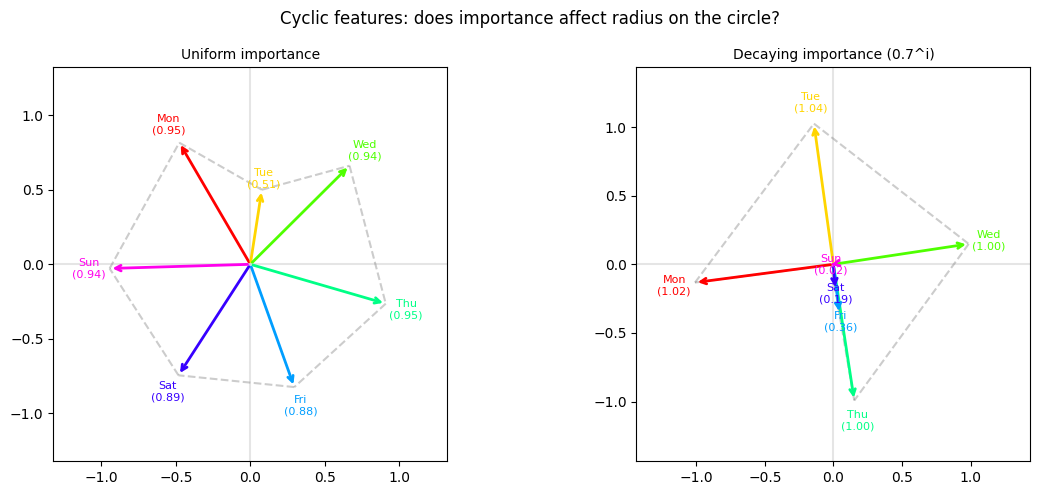


Feature norms vs importance (decaying importance model):
  Mon: norm=1.018, importance=1.000
  Tue: norm=1.035, importance=0.700
  Wed: norm=0.997, importance=0.490
  Thu: norm=1.004, importance=0.343
  Fri: norm=0.364, importance=0.240
  Sat: norm=0.186, importance=0.168
  Sun: norm=0.018, importance=0.118

Correlation(norm, importance) = 0.782


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for col, (name, res) in enumerate(imp_results.items()):
    ax = axes[col]
    model = res['model']
    
    W = None
    for pname, param in model.encoder.named_parameters():
        if 'weight' in pname:
            W = param.detach().cpu().numpy()
            break
    
    if W is not None:
        norms = np.linalg.norm(W, axis=0)
        
        for i in range(n_cyclic):
            color = plt.cm.hsv(i / n_cyclic)
            ax.annotate('', xy=(W[0, i], W[1, i]), xytext=(0, 0),
                       arrowprops=dict(arrowstyle='->', color=color, lw=2))
            ax.text(W[0, i]*1.15, W[1, i]*1.15,
                   f'{day_labels[i]}\n({norms[i]:.2f})',
                   ha='center', va='center', fontsize=8, color=color)
        
        # Connect in order
        for i in range(n_cyclic):
            j = (i + 1) % n_cyclic
            ax.plot([W[0, i], W[0, j]], [W[1, i], W[1, j]], 'k--', alpha=0.2)
    
    max_r = np.max(np.abs(W)) * 1.4
    ax.set_xlim(-max_r, max_r)
    ax.set_ylim(-max_r, max_r)
    ax.set_aspect('equal')
    ax.set_title(name, fontsize=10)
    ax.axhline(0, color='gray', alpha=0.2)
    ax.axvline(0, color='gray', alpha=0.2)

plt.suptitle('Cyclic features: does importance affect radius on the circle?', fontsize=12)
plt.tight_layout()
plt.show()

# Print norms vs importance
print("\nFeature norms vs importance (decaying importance model):")
W_imp = None
for pname, param in imp_results['Decaying importance (0.7^i)']['model'].encoder.named_parameters():
    if 'weight' in pname:
        W_imp = param.detach().cpu().numpy()
norms_imp = np.linalg.norm(W_imp, axis=0)
imp_vals = importance.cpu().numpy()
for i in range(n_cyclic):
    print(f"  {day_labels[i]}: norm={norms_imp[i]:.3f}, importance={imp_vals[i]:.3f}")
print(f"\nCorrelation(norm, importance) = {np.corrcoef(norms_imp, imp_vals)[0,1]:.3f}")

## 8. Theoretical analysis: why should similarity be preserved?

Consider two features i, j that co-activate with probability p_ij > p_i * p_j (positively correlated). When both are active, the reconstruction error is:

$$E[\|x - \hat{x}\|^2 | i,j \text{ active}] = \|x_i w_i + x_j w_j - \text{decode}(x_i w_i + x_j w_j)\|^2$$

If w_i and w_j point in similar directions, their sum amplifies the signal (constructive interference). If they point in opposite directions, they cancel (destructive interference).

For co-activating features, **constructive interference is cheaper** because the model can use the combined signal to reconstruct both. This creates pressure for correlated features to have similar directions.

For anti-correlated features (never co-activate), interference doesn't matter, so they can be orthogonal or even antipodal.

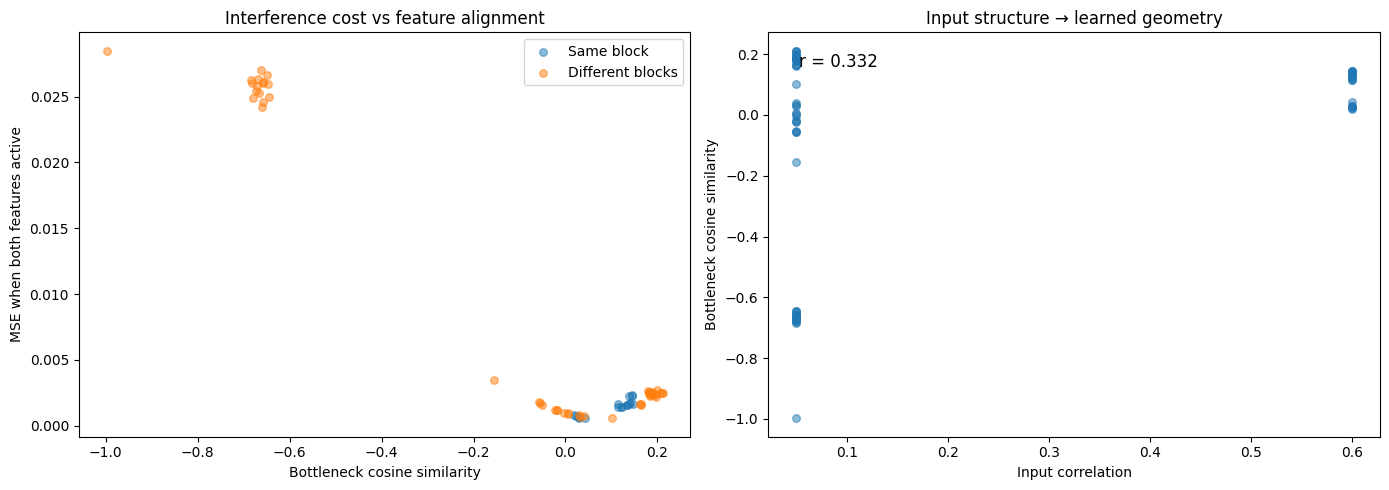

In [18]:
# Empirically verify: plot interference cost for aligned vs misaligned feature pairs
# Use the block-correlated model

model = results['Block (3 groups)']['model']
model.eval()

W = None
for pname, param in model.encoder.named_parameters():
    if 'weight' in pname:
        W = param.detach()
        break

# For each pair of features, compute:
# 1. Their cosine similarity in bottleneck
# 2. The reconstruction error when both are active simultaneously
# 3. Whether they're in the same block

C_in = C_block.numpy()
pair_data = []

with torch.no_grad():
    for i in range(n):
        for j in range(i+1, n):
            # Create input with both features active
            x_both = torch.zeros(1000, n, device=device)
            x_both[:, i] = torch.rand(1000, device=device)
            x_both[:, j] = torch.rand(1000, device=device)
            
            x_recon, _ = model(x_both)
            mse_both = nn.functional.mse_loss(x_recon, x_both).item()
            
            # Cosine similarity in bottleneck
            wi = W[:, i]
            wj = W[:, j]
            cos_sim_val = (torch.dot(wi, wj) / (wi.norm() * wj.norm() + 1e-8)).item()
            
            pair_data.append({
                'i': i, 'j': j,
                'input_corr': C_in[i, j],
                'cos_sim': cos_sim_val,
                'mse_both_active': mse_both,
                'same_block': C_in[i, j] > 0.3,
            })

import pandas as pd
df_pairs = pd.DataFrame(pair_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Interference cost vs cosine similarity
ax = axes[0]
same = df_pairs[df_pairs['same_block']]
diff = df_pairs[~df_pairs['same_block']]
ax.scatter(same['cos_sim'], same['mse_both_active'], alpha=0.5, label='Same block', s=30)
ax.scatter(diff['cos_sim'], diff['mse_both_active'], alpha=0.5, label='Different blocks', s=30)
ax.set_xlabel('Bottleneck cosine similarity')
ax.set_ylabel('MSE when both features active')
ax.set_title('Interference cost vs feature alignment')
ax.legend()

# Input correlation vs bottleneck cosine similarity
ax = axes[1]
ax.scatter(df_pairs['input_corr'], df_pairs['cos_sim'], alpha=0.5, s=30)
ax.set_xlabel('Input correlation')
ax.set_ylabel('Bottleneck cosine similarity')
ax.set_title('Input structure → learned geometry')
r = df_pairs['input_corr'].corr(df_pairs['cos_sim'])
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=12, va='top')

plt.tight_layout()
plt.show()

## 9. Summary and connections

### Key connections:

1. **Engels/Tegmark circular features**: Our toy model reproduces this — when features have cyclic correlation structure, the bottleneck learns a circular arrangement in 2D. Adjacent features (Mon↔Tue) have higher cosine similarity than distant ones (Mon↔Thu).

2. **Feature splitting**: As correlation structure goes from coarse (few groups) to fine (many groups) to independent, the bottleneck geometry transitions smoothly. Coarse features that "split" into fine features remain geometrically nearby — exactly as observed in SAEs with increasing dictionary size.

3. **Superposition + similarity**: At high compression, the autoencoder is forced into superposition. The correlation structure of inputs determines *which* features share dimensions. Correlated features share more → higher cosine similarity. This is a geometric consequence of minimizing interference: co-activating features benefit from constructive interference (aligned directions), while anti-correlated features can safely be orthogonal or antipodal.

4. **Importance modulates radius, correlation modulates angle**: With importance weighting, high-importance features get larger norms (further from origin), while correlation structure determines angular relationships. These are orthogonal degrees of freedom.

### Open questions:
- Does encoder depth (nonlinearity) help preserve similarity structure better than linear?
- How does this interact with signed features (see `signed_features.ipynb`)?
- At what compression ratio does the similarity structure break down?
- Can we derive the optimal geometry for a given correlation structure analytically?